# 代理知识总结：模型上下文协议（MCP）

## 概述
- 为了让大型语言模型（LLM）更有效地作为智能代理，需要扩展其能力，支持与外部环境交互，包括访问当前数据、外部软件和执行特定操作任务。
- 模型上下文协议（MCP）应运而生，提供一个标准化接口，让LLM能与外部资源（系统、数据库、工具等）连接，实现一致且可预测的集成。

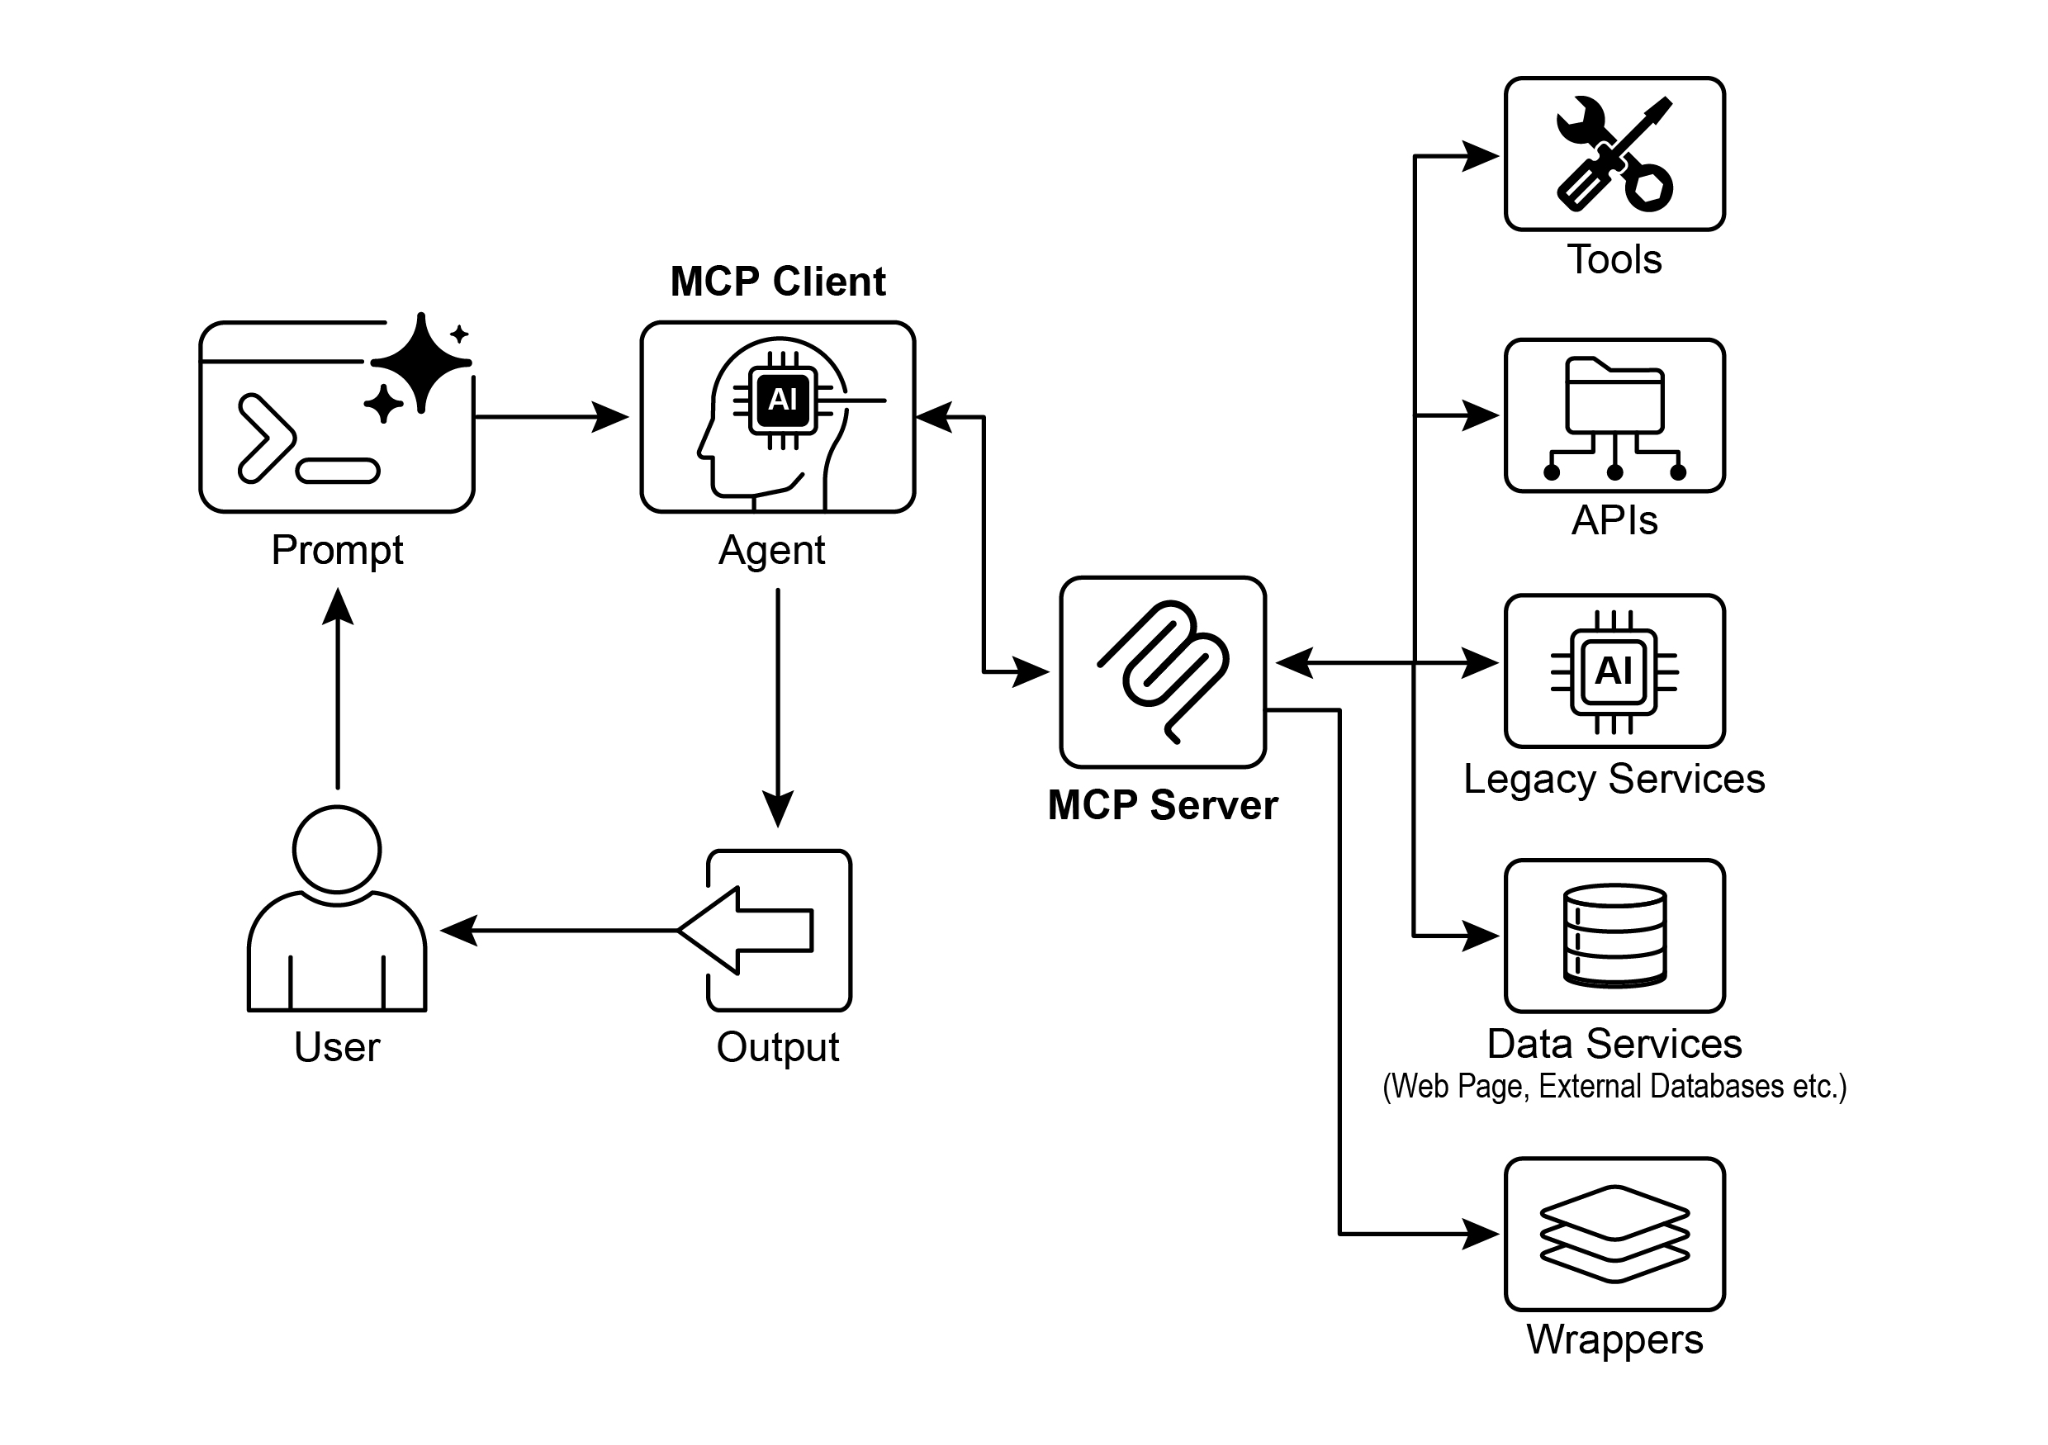

## MCP的工作原理
- MCP充当一种通用适配器，使LLM无需为每个外部系统开发自定义集成。
- MCP是开放标准，支持主流LLM（如Gemini、OpenAI GPT模型、Mixtral、Claude）与外部应用、数据源和工具通信。
- MCP通过客户端-服务器架构工作，定义数据（资源）、交互模板（提示）和可执行工具等元素对外暴露，由MCP服务器消费。

## MCP的设计要点及挑战
- MCP是一种“代理接口”的契约，其效果依赖于设计良好的API。
- 不能仅简单包装已有遗留API，否则可能效率低下或不准确（例如：票务API限制逐条查询，高优先级工单汇总时效率低）。
- 需要增强API，比如支持确定性过滤和排序，以帮助非确定性代理高效工作。
- MCP能封装的API数据必须对代理友好和可理解，MCP自己不负责强制保证数据格式。
- 比如PDF格式数据对代理是无用的，先转换成结构化数据（如Markdown）更合适。
- 开发者须关注连接方式和数据交换的本质，确保真正兼容和高效。

## MCP（模型上下文协议）与工具调用的区别总结

### 1. 工具函数调用（Tool Function Calling）
- **定义**：LLM（大型语言模型）针对特定、预定义的工具或函数发起请求。
- **交互方式**：点对点、一对一互动。
- **实现细节**：LLM格式化请求，发送给执行代码，代码执行请求并返回结果给LLM。
- **特点**：
  - 直接访问特定功能，执行具体任务。
  - 紧耦合，工具集成通常依赖于具体函数接口。
  - 适合有限的、特定范围的功能调用。

### 2. 模型上下文协议（MCP, Model Context Protocol）
- **定义**：一种标准化接口，允许LLM与不同工具和系统进行广泛交互。
- **交互方式**：客户端-服务器架构，LLM作为客户端，可以连接多个MCP服务器（工具）。
- **特点**：
  - 跨工具、跨系统，支持动态发现和互操作性。
  - 支持可扩展的工具生态系统。
  - 促进工具的复用和独立开发，无需重新编写底层系统。
- **优势**：
  - 支持复杂的集成场景，适合互联的AI系统。
  - 通过开放协议提高兼容性。
  - 允许工具之间通过统一协议进行通信。

### 3. 对比总结表

| 特征          | 工具函数调用                     | 模型上下文协议（MCP）               |
| ------------- | ------------------------------ | --------------------------------- |
| **标准化**     | 私有且设备依赖                  | 开放标准，促进跨模型、跨工具互操作     |
| **范围**      | 针对具体、预定义函数场景         | 广泛框架，支持工具与LLM的动态发现与通信 |
| **架构**      | 一对一交互                      | 客户端-服务器架构，支持多工具接入     |
| **发现能力**  | 工具需明确嵌入对话上下文         | 动态发现工具及其能力，增强灵活性       |
| **复用性**    | 工具与具体函数紧耦合             | 支持独立、可复用、标准化工具           |

### 4. 总结与应用
- **工具函数调用**适合少量且明确的功能调用，简单直接。
- **MCP**则适合构建复杂、互联、多样化的AI生态系统，支持工具的动态扩展与互操作。
- MCP是未来构建通用、灵活智能系统的重要框架。

## MCP（模型上下文协议）代理知识总结

### MCP的额外考虑因素
- **工具 vs 资源 vs 提示**
  理解工具（执行动作的函数）、资源（静态数据）和提示（指导LLM与工具或资源交互的模板）三者的具体角色。

- **可发现性**
  MCP客户端可以动态查询服务器，了解可用的工具和资源，实现“即时发现”，无需重新部署。

- **安全性**
  需要强认证和授权，控制客户端访问的服务器和执行的动作，保障工具和数据安全。

- **实现复杂性**
  MCP作为开放标准，尽管复杂，有些模型提供商提供SDK简化开发，方便MCP客户端和服务器的连接。

- **错误处理**
  明确定义错误处理策略，将错误信息返回给LLM，使其能理解错误并采取备用方案。

- **本地 vs 远程服务器**
  本地服务器适合对敏感数据和速度要求高的场景，远程服务器便于共享和扩展。

- **按需 vs 批量处理**
  支持按需交互和批量处理，满足实时会话和大规模数据处理需求。

- **传输机制**
  支持JSON-RPC、HTTP、SSE等多种传输协议，确保有效的客户端-服务器通信。

### MCP的组件
1. **大语言模型（LLM）**
   核心智能，处理请求、制定计划、决定是否调用外部工具。

2. **MCP客户端**
   LLM的代理，将LLM的意图转化为符合MCP标准的请求，负责发现、连接及通信。

3. **MCP服务器**
   网关，向MCP客户端暴露工具、资源和提示，通常负责特定领域的数据或服务。

4. **第三方服务（3P）**
   代表实际的外部工具或数据源（如数据库、SaaS平台或公共API），执行具体操作。

### 交互流程
1. **发现**
   MCP客户端询问服务器，获取可用工具、资源和提示的列表。

2. **请求制定**
   LLM决定使用的工具，并构建请求，包括所用工具和参数。

3. **客户端通信**
   MCP客户端发送标准化请求到相应的MCP服务器。

4. **服务器执行**
   MCP服务器验证请求并调用相应软件功能执行操作。

5. **响应和上下文更新**
   服务器发送执行结果给客户端，客户端告知LLM，LLM更新上下文，继续后续步骤。

## 实践应用与用例总结

MCP（模型上下文协议）大幅拓展了AI/LLM的能力，使其更强大且多样化。以下是九个关键用例：

1. **数据库集成**
   使LLM和智能代理可无缝访问和操作结构化数据库数据，如查询Google BigQuery实现实时信息获取和操作。

2. **生成媒体编排**
   通过MCP工具与先进生成媒体服务（如Google Imagen、Veo、Chirp3 HD、Lyria）集成，实现图像生成、视频制作、语音合成和音乐创作等动态内容。

3. **外部API交互**
   标准化LLM调用外部API的方式，并能获取实时数据，实现天气、股票、邮件等系统的互动，扩展语言模型的能力边界。

4. **基于推理的信息提取**
   利用强大的推理技巧，实现复杂、依赖查询的高效信息提取，超过传统搜索和检索系统。

5. **定制工具开发**
   开发者可创建自定义工具，通过MCP暴露给LLM和代理，允许内部函数或系统标准化调用，简化集成且无需修改模型本身。

6. **标准化LLM-应用通信**
   确保LLM与应用间通信一致，降低整合开销，提高跨不同提供商与主机应用的互操作性，方便复杂代理系统开发。

7. **复杂工作流编排**
   组合MCP的多工具和数据源，支持高复杂度、多步骤工作流，如客户数据检索、个性化营销内容生成与发送。

8. **物联网设备控制**
   实现对智能家居、工业传感器、机器人等IoT设备的自然语言指令控制和自动化，实现设备联动。

9. **金融服务自动化**
   使LLM能连接金融数据源及平台，进行市场数据分析、交易执行、合规报告生成及个性化财务建议，确保安全标准化通信。



### 使用 ADK 的实践代码示例

In [ ]:
import os
from google.adk.agents import LlmAgent
from google.adk.tools.mcp_tool.mcp_toolset import MCPToolset, StdioServerParameters

## 创建一个可靠的绝对路径，指向名为 'mcp_managed_files' 的文件夹
## 该文件夹位于此智能体所在的同一目录中。
## 这确保了智能体即用地进行演示。
## 对于生产环境，您需要将此路径指向一个更持久和安全的位置。
TARGET_FOLDER_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__)), "mcp_managed_files")

## 在智能体之前确保目标目录存在。
os.makedirs(TARGET_FOLDER_PATH, exist_ok=True)

root_agent = LlmAgent(
    model='gemini-2.0-flash',
    name='filesystem_assistant_agent',
    instruction=(
        'Help the user manage their files. You can list files, read files, and write files. '
        f'You are operating in the following directory: {TARGET_FOLDER_PATH}'
    ),
    tools=[
        MCPToolset(
            connection_params=StdioServerParameters(
                command='npx',
                args=[
                    "-y",  # npx 的参数，用于自动确认安装
                    "@modelcontextprotocol/server-filesystem",
                    # 这必须是文件夹的绝对路径。
                    TARGET_FOLDER_PATH,
                ],
            ),
            # 可选：您可以过滤从 MCP 服务器公开的工具。
            # 例如，仅允许读取：
            # tool_filter=['list_directory', 'read_file']
        )
    ],
)

### 使用 FastMCP 创建 MCP 服务器

FastMCP 是一个高级 Python 框架，旨在简化 MCP 服务器的开发。它提供了一个抽象层，简化了协议的复杂性，允许开发者专注于核心逻辑。

该库使用简单的 Python 装饰器能够快速定义工具、资源和提示词。一个显著的优势是其自动模式生成，它智能地解释 Python 函数签名、类型提示和文档字符串，以构建必要的 AI 模型接口规范。这种自动化最大限度地减少了手动配置并减少了人为错误。

除了基本的工具创建之外，FastMCP 还促进了服务器组合和代理等高级架构模式。这使得能够模块化开发复杂的、多组件系统，并将现有服务无缝集成到 AI 可访问的框架中。此外，FastMCP 包括针对高效、分布式和可扩展的 AI 驱动应用程序的优化

In [ ]:
## fastmcp_server.py
## 此脚本演示如何使用 FastMCP 创建一个简单的 MCP 服务器。
## 它公开一个生成问候语的单一工具。

## 1. 确保您已安装 FastMCP：
## pip install fastmcp

from fastmcp import FastMCP, Client

## 初始化 FastMCP 服务器。
mcp_server = FastMCP()

## 定义一个简单的工具函数。
## `@mcp_server.tool` 装饰器将此 Python 函数注册为 MCP 工具。
## 文档字符串成为 LLM 的工具描述。
@mcp_server.tool
def greet(name: str) -> str:
    """
    生成个性化的问候语。

    参数：
        name: 要问候的人的名字。

    返回：
        问候语字符串。
    """
    return f"Hello, {name}! Nice to meet you."

## 或者如果您想从脚本运行它：
if __name__ == "__main__":
    mcp_server.run(
        transport="http",
        host="127.0.0.1",
        port=8000
    )

### 使用 ADK 智能体消费 FastMCP 服务器

In [ ]:
import datasurfer as ds
agent = ds.Agent('AAA', 
                 name='fastmcp_greeter_agent',
                 instructions='You are a friendly assistant that can greet people by their name. Use the "greet" tool.',
                 mcp_servers=[{'url': 'http://127.0.0.1:8000/mcp', 'tools': ['get_current_time']}], tools='none')

await agent.resp('What time is now?')


Fastmcp_greeter_agent (Assistant):

    Function Call:
        Name: get_current_time
        Arguments: {}
        Call ID: call_kzdP4YaBJgDEfdV7oru03XWu


--------------------------------------------------------------------------------------------------------

Fastmcp_greeter_agent (Assistant):

    The current time is 11:43 AM on May 10, 2026. How can I assist you further?

--------------------------------------------------------------------------------------------------------



'The current time is 11:43 AM on May 10, 2026. How can I assist you further?'

## 关键要点

以下是本章核心要点：

- 模型上下文协议（MCP）是一个开放标准，促进 LLM 与外部应用程序、数据源和工具之间的标准化通信
- 它采用客户端-服务器架构，定义了公开和使用资源、提示和工具的方法
- 智能体开发工具包（ADK）支持使用现有 MCP 服务器以及通过 MCP 服务器公开 ADK 工具
- FastMCP 简化了 MCP 服务器的开发和管理，特别是用于公开在 Python 中实现的工具
- 生成媒体服务的 MCP 工具允许智能体与 Google Cloud 的生成媒体能力（Imagen、Veo、Chirp 3 HD、Lyria）集成
- MCP 使 LLM 和智能体能够与现实世界系统交互，访问动态信息，并执行超越文本生成的操作

## 结论
模型上下文协议（MCP）是一个开放标准，促进大型语言模型（LLM）与外部系统之间的通信。它采用客户端-服务器架构，使 LLM 能够通过标准化工具访问资源、使用提示和执行操作。MCP 允许 LLM 与数据库交互、管理生成媒体工作流、控制物联网设备以及自动化金融服务。实际示例演示了设置智能体与 MCP 服务器通信的方法，包括文件系统服务器和使用 FastMCP 构建的服务器，说明了其与智能体开发工具包（ADK）的集成。MCP 是开发超越基本语言能力的交互式 AI 智能体的关键组件。